In [1]:
import pandas as pd   #for data manipulation
import numpy as np    #Numerical operations
import warnings
warnings.filterwarnings('ignore')      #supress non-critical warnings

In [2]:
df = pd.read_csv('german_credit_data.csv', index_col = 0) #index_col = 0 tells that unnamed first col is index

In [3]:
print("Shape:", df.shape) #tells how many rows and features there are

Shape: (1000, 9)


In [4]:
print("\nColumn Names: \n", df.columns.tolist())  #lists column names


Column Names: 
 ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


In [6]:
print("\nData Type: \n", df.dtypes)  #tells the data type for each column in the DataFrame


Data Type: 
 Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object


In [7]:
print ("\nMissing Values: \n", df.isnull().sum())  #check missing values


Missing Values: 
 Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64


In [8]:
print("\nFirst 5 Rows: \n", df.head())


First 5 Rows: 
    Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  
0         6             radio/TV  
1        48             radio/TV  
2        12            education  
3        42  furniture/equipment  
4        24                  car  


In [9]:
np.random.seed(42)  #42 for reproducibility

In [10]:
default_prob = np.full(len(df), 0.20)  #we start with a base PD of 20%; np. np.full creates an array of length 1000, filled with 0.20

In [11]:
default_prob[df['Checking account'] == 'little'] += 0.15   #0.15 because someone with little checking account balance is more likely to default
default_prob[df['Checking account'].isnull()] += 0.10    #0.10 because no value in the checking account is likely a moderate to high risk signal and since we are unsure of it, we keep 0.10

In [12]:
default_prob[df['Saving accounts'] == 'little'] += 0.10
default_prob[df['Saving accounts'].isnull()] += 0.08
# Low savings = less buffer against income shocks = higher default risk

In [14]:
default_prob[df['Duration'] > 36] += 0.10
default_prob[df['Duration'] > 48] += 0.05
# Longer loans carry more uncertainty about future repayment capacity.
# A 48-month loan is riskier than a 6-month loan, all else equal.
# We apply two increments: the second is additive for very long durations.


In [15]:
high_amount_threshold = df['Credit amount'].quantile(0.75)
default_prob[df['Credit amount'] > high_amount_threshold] += 0.08
# Higher loan amounts relative to a typical borrower increase default risk.
# We use the 75th percentile as the threshold for "large" loans.

In [16]:
default_prob[df['Job'] == 0] += 0.10
# Job == 0 in this dataset means unskilled and non-resident.
# This group has the weakest income stability.

In [17]:
default_prob = np.clip(default_prob, 0, 0.85)
# No one should have a near-certain default probability in a simulated dataset.
# Capping also prevents values above 1.0 after all the additive increments.

In [18]:
df['Risk']= (np.random.uniform (0, 1, len(df)) < default_prob).astype(int)
# For each borrower, we draw a Bernoulli trial.
# If a random number between 0 and 1 is LESS than their default_prob, they default.
# 1 = default (bad), 0 = no default (good)
# astype(int) converts True/False to 1/0.
#This is the key insight: **the larger the default_prob, the larger the target zone that a random number has to fall into to trigger a default.**
#A borrower with p = 0.80 will default for any draw below 0.80, which covers 80% of the [0,1] interval. A borrower with p = 0.20 only defaults if the draw lands in the bottom 20%.
#Visually:
#```
#Borrower with p = 0.20:
#|████░░░░░░░░░░░░░░░░░░░░░░░░░░|
# 0                              1
# ↑ defaults here (20%)    ↑ no default (80%)

#Borrower with p = 0.80:
#|████████████████████████░░░░░░|
# 0                              1
# ↑ defaults here (80%)    ↑ no default (20%)

In [19]:
print ("Default Rate:", df['Risk'].mean().round(3))
print("Default Count:", df['Risk'].sum())
print ("Non-Default Count:", len(df) - df['Risk'].sum())
print ("Non-default Count:", (df['Risk'] == 0).sum())

Default Rate: 0.413
Default Count: 413
Non-Default Count: 587
Non-default Count: 587


In [20]:
print(df.shape)
print(df.columns.tolist)

(1000, 10)
<bound method IndexOpsMixin.tolist of Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')>


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
numeric_cols = ['Age', 'Credit amount', 'Duration']
print(df[numeric_cols].describe().round(2))

           Age  Credit amount  Duration
count  1000.00        1000.00   1000.00
mean     35.55        3271.26     20.90
std      11.38        2822.74     12.06
min      19.00         250.00      4.00
25%      27.00        1365.50     12.00
50%      33.00        2319.50     18.00
75%      42.00        3972.25     24.00
max      75.00       18424.00     72.00


In [30]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for col in categorical_cols:
    table = df.groupby(col, dropna=False)['Risk'].agg(
        Total = 'count',
        Defaults = 'sum'
    )
    table['Default Rate'] = (table['Defaults']/table['Total']).round(3)
    print (table.sort_values('Default Rate', ascending = False).to_string())

        Total  Defaults  Default Rate
Sex                                  
female    310       128         0.413
male      690       285         0.413
     Total  Defaults  Default Rate
Job                               
0       22        11         0.500
2      630       261         0.414
3      148        61         0.412
1      200        80         0.400
         Total  Defaults  Default Rate
Housing                               
free       108        46         0.426
own        713       295         0.414
rent       179        72         0.402
                 Total  Defaults  Default Rate
Saving accounts                               
little             603       271         0.449
NaN                183        76         0.415
quite rich          63        22         0.349
rich                48        14         0.292
moderate           103        30         0.291
                  Total  Defaults  Default Rate
Checking account                               
little            

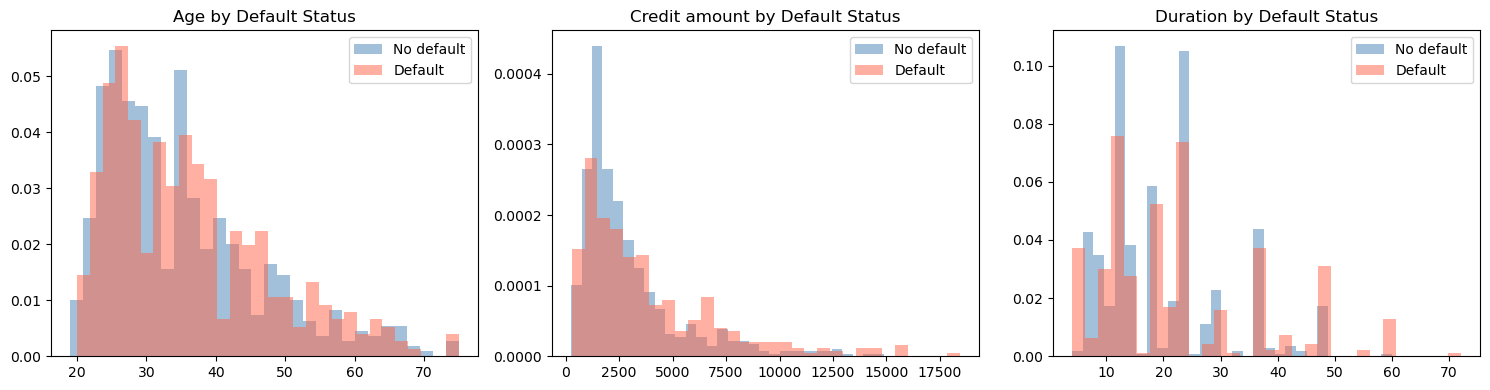

Plot Saved.


In [31]:
fig, axes = plt.subplots(1,3, figsize = (15, 4))

for i, col in enumerate (['Age', 'Credit amount', 'Duration']):
    for risk_val, label, color in [(0, 'No default', 'steelblue'),
                                  (1, 'Default', 'tomato')]:
        axes[i].hist(
            df[df['Risk'] == risk_val][col],
            bins = 30,
            alpha = 0.5,
            label = label,
            color = color,
            density = True
        )
    axes[i].set_title(f'{col} by Default Status')
    axes[i].legend()

plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', dpi = 150, bbox_inches='tight')
plt.show()
print ("Plot Saved.")

In [32]:
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')
# Replace NaN in categorical columns with the string 'unknown'.
# We don't impute with mode or any observed category.
# 'unknown' becomes its own bin, and it will receive its own WOE value based on its actual default rate.

In [36]:
print (df[['Saving accounts', 'Checking account']].isnull().sum())

Saving accounts     0
Checking account    0
dtype: int64


In [37]:
merge_map = {
    'vacation/others' : 'repairs/other',
    'repairs' : 'repairs/other',
    'domestic appliances' : 'radio/TV'
}
df['Purpose'] = df['Purpose'].replace(merge_map)
print(df['Purpose'].value_counts())

Purpose
car                    337
radio/TV               292
furniture/equipment    181
business                97
education               59
repairs/other           34
Name: count, dtype: int64


In [38]:
# From EDA, vacation/others (n=12) and repairs (n=22) are too small
# to be reliable standalone bins.
# We merge them based on TWO criteria, both must be satisfied:
#   1. Small cell size (below ~50 observations)
#   2. Similar default rates (so merging does not destroy information)
#
# vacation/others: 66.7%, repairs: 50.0%
# These are directionally similar (both high risk) so merging is defensible.
# domestic appliances (n=12, 25.0%) is small but its rate is close to
# radio/TV (35.7%), so we merge it there instead.

In [40]:
df['log_credit_amount'] = np.log1p(df['Credit amount'])
df['log_duration'] = np.log1p(df['Duration'])
print (df[['Credit amount', 'log_credit_amount', 'Duration', 'log_duration']].describe().round(3))
# From EDA: Credit amount and Duration are right-skewed.
# Logistic regression estimates a linear boundary in log-odds space.
# A heavily skewed input variable compresses most observations into a narrow range, giving the model very little to work with for the majority of borrowers
# while a handful of extreme values pull the coefficient disproportionately.
#
# Log transformation compresses the long right tail, spreads out the lower values, and produces a distribution much closer to symmetric.
# This makes the linear assumption in logistic regression far more appropriate.
#
# We use log1p (log(1 + x)) instead of log(x) as a safety measure.
# log(0) is undefined (negative infinity). log1p never hits that problem because 1 + x is always at least 1 for non-negative inputs.
# Credit amount and Duration have no zeros in this dataset, but log1p is the correct habit to build for production code.


       Credit amount  log_credit_amount  Duration  log_duration
count       1000.000           1000.000  1000.000      1000.000
mean        3271.258              7.789    20.903         2.941
std         2822.737              0.776    12.059         0.546
min          250.000              5.525     4.000         1.609
25%         1365.500              7.220    12.000         2.565
50%         2319.500              7.750    18.000         2.944
75%         3972.250              8.287    24.000         3.219
max        18424.000              9.821    72.000         4.290


In [42]:
df['Job'] = df['Job'].astype(str)
print (df['Job'].value_counts())
# Job is currently stored as integers 0, 1, 2, 3.
# These look numeric, but they are ordinal categories, not a continuous quantity.
# Leaving them as integers would tell the model that Job=2 is exactly twice Job=1, which has no meaning.
#
# Converting to string ensures WOE binning treats each job level as a separate category with its own WOE value.

Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64


In [43]:
from sklearn.model_selection import train_test_split
features = ['Age', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'log_credit_amount', 'log_duration', 'Purpose']
X = df[features]
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
print (f"Train Size: {len(X_train)} | Default Rate: {y_train.mean():.3f}")
print (f"Test Size: {len(X_test)} | Default Rate: {y_test.mean():.3f}")
# Define features and target.
# We exclude the original Credit amount and Duration since we have their log-transformed versions.
# We exclude Sex because it is a protected characteristic under EU anti-discrimination law and has near-zero predictive power.
#
# X is the feature matrix. y is the target vector.
# Keeping them separate is the sklearn convention and prevents accidental data leakage where the target influences features.
#
# 80% of data goes to training, 20% to testing.
# With 1,000 rows, this gives 800 training and 200 test observations.
# The test set is held completely aside and never touched
# until final model evaluation. Touching it earlier is data leakage.
#
# random_state=42 Fixes the split so it is reproducible.
#
# stratify=y Ensures the default rate in train and test sets matches the overall default rate in the full dataset.
# Without stratify, random sampling might give you a test set with 35% defaults when the overall rate is 41%.
# That mismatch would make evaluation metrics misleading.

Train Size: 800 | Default Rate: 0.412
Test Size: 200 | Default Rate: 0.415


In [45]:
def calculate_woe_iv(df, feature, target):
    """
    Calculate WOE and IV for a single categorical feature.

    Parameters:
        df      : the full dataframe
        feature : column name of the categorical variable
        target  : column name of the binary target (1=default, 0=no default)

    Returns:
        woe_df  : dataframe with WOE per bin
        iv      : scalar IV for the whole variable
    """
    total_defaults = df[target].sum()
    total_non_defaults = (df[target] == 0).sum()
    grouped = df.groupby(feature, dropna=False)[target].agg(
        Defaults = 'sum',
        Total = 'count'
    )
    grouped['Non_Defaults'] = grouped['Total'] - grouped['Defaults']
    grouped['pct_defaults'] = grouped['Defaults']/total_defaults
    grouped['pct_non_defaults'] = grouped['Non_Defaults'] / total_non_defaults

    grouped['pct_defaults'] = grouped['pct_defaults'].replace(0, 0.0001)
    grouped['pct_non_defaults'] = grouped['pct_non_defaults'].replace(0, 0.0001)

    grouped['WOE'] = np.log(
        grouped['pct_non_defaults']/grouped['pct_defaults']
    )

    grouped['iv_contribution'] = (grouped['pct_non_defaults'] - grouped['pct_defaults']) * grouped['WOE']

    iv = grouped['iv_contribution'].sum()

    woe_df = grouped[['Total', 'Defaults', 'Non_Defaults', 'pct_defaults', 'pct_non_defaults', 'WOE', 'iv_contribution']].round(4)

    return woe_df, round(iv, 4)

features_to_test = ['Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

iv_summary = {}

for feat in features_to_test:
    woe_df, iv = calculate_woe_iv(df, feat, 'Risk')
    iv_summary[feat] = iv
    print(f"\n{'='*55}")
    print(f"Variable: {feat}  |  IV = {iv}")
    print('='*55)
    print(woe_df.to_string())

print("\n\n=== IV SUMMARY ===")
iv_series = pd.Series(iv_summary).sort_values(ascending=False)
print(iv_series)


Variable: Job  |  IV = 0.0034
     Total  Defaults  Non_Defaults  pct_defaults  pct_non_defaults     WOE  iv_contribution
Job                                                                                        
0       22        11            11        0.0266            0.0187 -0.3516           0.0028
1      200        80           120        0.1937            0.2044  0.0539           0.0006
2      630       261           369        0.6320            0.6286 -0.0053           0.0000
3      148        61            87        0.1477            0.1482  0.0035           0.0000

Variable: Housing  |  IV = 0.0007
         Total  Defaults  Non_Defaults  pct_defaults  pct_non_defaults     WOE  iv_contribution
Housing                                                                                        
free       108        46            62        0.1114            0.1056 -0.0531           0.0003
own        713       295           418        0.7143            0.7121 -0.0031           0.000

In [47]:
def bin_continuous_variable(df, col, n_bins = 5):
    """
    Bin a continuous variable into quantile-based bins.
    Quantile binning ensures roughly equal population per bin,
    which is important for stable WOE estimation.
    Equal-width binning would produce thin bins at the extremes
    where extreme values cluster, leading to unreliable WOE values
    for exactly the borrowers who are hardest to score.
    """
    binned_col = col + '_bin'
    df[binned_col] = pd.qcut(
        df[col],
        q = n_bins,
        duplicates = 'drop'
    )
    df[binned_col] = df[binned_col].astype(str)
    return df, binned_col

for col in ['Age', 'log_credit_amount', 'log_duration']:
    df, binned_col = bin_continuous_variable (df, col)
    woe_df, iv = calculate_woe_iv(df, binned_col, 'Risk')
    print(f"\nVariable: {col}  |  IV = {iv}")
    print(woe_df[['Total','Defaults','WOE','iv_contribution']].to_string())


Variable: Age  |  IV = 0.0237
                Total  Defaults     WOE  iv_contribution
Age_bin                                                 
(18.999, 26.0]    240        89  0.1771           0.0074
(26.0, 30.0]      171        72 -0.0331           0.0002
(30.0, 36.0]      216        82  0.1395           0.0041
(36.0, 45.0]      187        87 -0.2123           0.0086
(45.0, 75.0]      186        83 -0.1357           0.0035

Variable: log_credit_amount  |  IV = 0.1136
                       Total  Defaults     WOE  iv_contribution
log_credit_amount_bin                                          
(5.524, 7.141]           201        77  0.1249           0.0031
(7.141, 7.554]           199        66  0.3491           0.0233
(7.554, 7.956]           200        72  0.2238           0.0098
(7.956, 8.46]            200        85 -0.0493           0.0005
(8.46, 9.821]            200       113 -0.6131           0.0769

Variable: log_duration  |  IV = 0.0589
                  Total  Defaults    

In [59]:
def bin_duration_monotonic(df):
    conditions = [
        df['log_duration'] <= 3.434,
        df['log_duration'] >  3.434
    ]
    labels = ['short_to_medium', 'long']
    df['log_duration_bin'] = np.select(conditions, labels, default='unknown')
    return df

df = bin_duration_monotonic(df)

woe_df, iv = calculate_woe_iv(df, 'log_duration_bin', 'Risk')
print(f"log_duration  |  IV = {iv}")
print(woe_df[['Total', 'Defaults', 'WOE', 'iv_contribution']].to_string())

log_duration  |  IV = 0.0543
                  Total  Defaults     WOE  iv_contribution
log_duration_bin                                          
long                173        93 -0.5022           0.0446
short_to_medium     827       320  0.1086           0.0097


In [76]:
def build_woe_encoder(df, features, target):
    """
    Build a WOE lookup dictionary for all features.
    
    For each feature, stores a mapping of:
        bin label --> WOE value
    
    This dictionary is fitted on the TRAINING set only.
    It is then applied to both train and test sets.
    Fitting on the full dataset would be data leakage because
    the test set's default outcomes would influence the WOE
    values used to score it.
    """
    woe_encoder = {}
    
    for feat in features:
        total_defaults     = df[target].sum()
        total_non_defaults = (df[target] == 0).sum()
        
        grouped = df.groupby(feat, dropna=False)[target].agg(
            Defaults='sum',
            Total='count'
        )
        grouped['Non_Defaults']      = grouped['Total'] - grouped['Defaults']
        grouped['pct_defaults']      = grouped['Defaults']     / total_defaults
        grouped['pct_non_defaults']  = grouped['Non_Defaults'] / total_non_defaults
        grouped['pct_defaults']      = grouped['pct_defaults'].replace(0, 0.0001)
        grouped['pct_non_defaults']  = grouped['pct_non_defaults'].replace(0, 0.0001)
        grouped['WOE']               = np.log(
                                           grouped['pct_non_defaults'] /
                                           grouped['pct_defaults']
                                       )
        woe_encoder[feat] = grouped['WOE'].to_dict()
        # Stores {bin_label: WOE_value} for each feature.
        # Example for Checking account:
        # {'little': -0.337, 'moderate': 0.237, 'rich': 0.342, 'unknown': 0.028}
    
    return woe_encoder


def apply_woe_encoding(df, woe_encoder):
    """
    Replace each feature's raw bin label with its WOE value.
    Creates new columns with suffix _WOE.
    Keeps original columns intact for auditability.
    """
    df_woe = df.copy()
    # .copy() prevents pandas from modifying the original dataframe.
    # Always copy before transforming to preserve the clean version.
    
    for feat, mapping in woe_encoder.items():
        df_woe[feat + '_WOE'] = df_woe[feat].map(mapping)
        # .map() replaces each value in the column using the dictionary.
        # Any value not found in the dictionary becomes NaN.
        # If NaN appears here it means a category exists in the test set
        # that was not in the training set. This is the unseen category
        # problem and must be handled in production.
    
    return df_woe

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ── Feature and target definition ──
final_features = [
    'log_credit_amount_bin',
    'Saving accounts',
    'Checking account',
    'Purpose',
    'log_duration_bin',
    'Age_bin'
]

X = df[final_features]
y = df['Risk']

# ── Train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Build WOE encoder on training set only ──
train_df = X_train.copy()
train_df['Risk'] = y_train.values
woe_encoder = build_woe_encoder(train_df, final_features, 'Risk')

# ── Apply WOE encoding ──
X_train_woe = apply_woe_encoding(X_train, woe_encoder)
X_test_woe  = apply_woe_encoding(X_test,  woe_encoder)

# ── Verify WOE columns exist before proceeding ──
print("X_train_woe columns:")
print(X_train_woe.columns.tolist())
# You must see _WOE columns here before going further.
# If you do not, stop and check that build_woe_encoder
# and apply_woe_encoding were defined and run successfully.

# ── Define WOE column names ──
woe_cols = [f + '_WOE' for f in final_features]

# ── Fit logistic regression ──
model = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model.fit(X_train_woe[woe_cols], y_train)

# ── Coefficients ──
coef_df = pd.DataFrame({
    'Feature'    : woe_cols,
    'Coefficient': model.coef_[0].round(4)
}).sort_values('Coefficient', ascending=False)
# Note: ascending=False not ascending='False'
# 'False' is a non-empty string which Python treats as True.
# This was a second bug in your original code.

print("\n=== MODEL COEFFICIENTS ===")
print(f"Intercept: {model.intercept_[0]:.4f}")
print(coef_df.to_string(index=False))

# ── Predicted probabilities ──
train_probs = model.predict_proba(X_train_woe[woe_cols])[:, 1]
test_probs  = model.predict_proba(X_test_woe[woe_cols])[:, 1]

# ── AUROC and Gini ──
train_auc = roc_auc_score(y_train, train_probs)
test_auc  = roc_auc_score(y_test,  test_probs)

print(f"\n=== AUROC ===")
print(f"Train: {train_auc:.4f}")
print(f"Test:  {test_auc:.4f}")

print(f"\n=== GINI ===")
print(f"Train: {2*train_auc-1:.4f}")
print(f"Test:  {2*test_auc-1:.4f}")

X_train_woe columns:
['log_credit_amount_bin', 'Saving accounts', 'Checking account', 'Purpose', 'log_duration_bin', 'Age_bin', 'log_credit_amount_bin_WOE', 'Saving accounts_WOE', 'Checking account_WOE', 'Purpose_WOE', 'log_duration_bin_WOE', 'Age_bin_WOE']

=== MODEL COEFFICIENTS ===
Intercept: -0.3525
                  Feature  Coefficient
     log_duration_bin_WOE      -0.2132
              Purpose_WOE      -0.8224
      Saving accounts_WOE      -0.8249
     Checking account_WOE      -0.9060
log_credit_amount_bin_WOE      -0.9073
              Age_bin_WOE      -0.9107

=== AUROC ===
Train: 0.6566
Test:  0.5480

=== GINI ===
Train: 0.3133
Test:  0.0961


In [80]:
from scipy.stats import ks_2samp

def compute_ks(y_true, y_prob):
    """
    Compute the KS statistic by comparing the PD distributions
    of defaulters and non-defaulters.
    
    ks_2samp tests whether two samples come from the same distribution.
    A high KS statistic means the two distributions are very different,
    which means the model separates defaults from non-defaults well.
    """
    defaults = y_prob[y_true == 1]
    non_defaults = y_prob[y_true == 0]

    ks_stat, p_value = ks_2samp(non_defaults, defaults)
    # ks_2samp returns the KS statistic and a p-value.
    # The p-value tests whether the two distributions are identical.
    # In credit risk we care about the statistic, not the p-value.

    return round(ks_stat, 4)

train_ks = compute_ks(y_train.values, train_probs)
test_ks = compute_ks(y_test.values, test_probs)
print(f"Train KS: {train_ks}")
print(f"Test KS: {test_ks}")

Train KS: 0.2421
Test KS: 0.1186


In [81]:
#All the validation techniques shows that we have overfitting issue
#Let's re-calibrate our model with regularisation
# C controls regularisation strength.
# Smaller C = stronger regularisation = more shrinkage of coefficients.
# C=1.0 is sklearn default. We try to check the C value with cross-validation
from sklearn.linear_model import LogisticRegressionCV

model = LogisticRegressionCV(
    Cs = [0.001, 0.01, 0.05, 0.1, 1.0, 10.0],  #c values to choose from
    cv = 5,         #5-fold cross-validation
    penalty = 'l2',  #we chose l2 because we already droped 2 features with weak IVs and our features are limited so we want stability therefore we don't use l1.
    solver = 'lbfgs',
    scoring = 'roc_auc',
    max_iter = 1000,
    random_state = 42
)
model.fit(X_train_woe[woe_cols], y_train)
print("Best C chosen:", model.C_[0])

Best C chosen: 1.0


In [82]:
#this shows that the problem is not with regularisation but with the data itself.
#the data is of only 1000 borrowers and noisy.
#and features are weak. At this moment nothing can be done about it.
#But I will still continue to see the end result.
#the purpose of this exercise is to understand the concept of credit modeling on varried datasets. And this is a perfect example for it

In [83]:
#Scorecard Scaling
#Factor = Points-to-double-the-odds/ ln(2)
#Offset = Base Score - Factor * ln(base odds)
BASE_SCORE = 600
BASE_ODDS = 1    #meaning 1:1 good to bad ratio, so ln(1) = 0
PDO = 20         #PDO: Typically 20. This means a borrower who scores 620 has twice the odds of being good compared to a borrower who scores 600.

import math
Factor = PDO/math.log(2)
Offset = BASE_SCORE - Factor * math.log(BASE_ODDS)

print (f"Factor: {Factor:.4f}")
print(f"Offset: {Offset:.4f}")

Factor: 28.8539
Offset: 600.0000


In [84]:
scorecard = {}
for feat, coef in zip (woe_cols, model.coef_[0]):
    woe_map = woe_encoder[feat.replace('_WOE', '')]
    bin_points = {}
    for bin_label, woe_val in woe_map.items():
        points = - (coef * woe_val * Factor)
        bin_points[bin_label] = round(points)
    scorecard[feat.replace('_WOE', '')] = bin_points

In [85]:
intercept_points = round(Offset + Factor + model.intercept_[0])
print("=== SCORECARD ===\n")
print(f'Base Points (from Intercept): {intercept_points}\n')

for feature, bins in scorecard.items():
    print(f"--- {feature} ---")
    for bin_label, points in bins.items():
        print(f"  {bin_label:<30} {points:>6} points")
    print()

=== SCORECARD ===

Base Points (from Intercept): 629

--- log_credit_amount_bin ---
  (5.524, 7.141]                      1 points
  (7.141, 7.554]                     12 points
  (7.554, 7.956]                      5 points
  (7.956, 8.46]                      -3 points
  (8.46, 9.821]                     -15 points

--- Saving accounts ---
  little                             -5 points
  moderate                           14 points
  quite rich                          9 points
  rich                               16 points
  unknown                             1 points

--- Checking account ---
  little                            -10 points
  moderate                            7 points
  rich                               18 points
  unknown                             0 points

--- Purpose ---
  business                           -2 points
  car                                 2 points
  education                          -2 points
  furniture/equipment                -5 points
  

In [86]:
def score_borrower(row, scorecard, intercept_points, woe_encoder):
    total = intercept_points
    for feature, bins in scorecard.items():
        bin_val = row[feature]
        points = bins.get(bin_val, 0)
        total += points
    return total

X_test_woe['Score'] = X_test.apply(
    lambda row: score_borrower (row, scorecard, intercept_points, woe_encoder),
    axis =1
)

print (X_test_woe['Score'].describe().round(1))

count    200.0
mean     628.9
std       16.6
min      592.0
25%      616.0
50%      629.5
75%      641.0
max      664.0
Name: Score, dtype: float64


In [87]:
X_test_woe['Default'] = y_test.values
print(X_test_woe.groupby('Default')['Score'].describe().round(1))

         count   mean   std    min    25%    50%    75%    max
Default                                                       
0        117.0  630.0  15.4  593.0  619.0  630.0  641.0  663.0
1         83.0  627.4  18.1  592.0  614.0  626.0  640.5  664.0
